In [1]:
%cd /mnt/sdd1/atharvas/formulacode/datasmith/
%load_ext autoreload
%autoreload 2


import pandas as pd

from datasmith import setup_environment

setup_environment()

/mnt/sdd1/atharvas/formulacode/datasmith


In [6]:
# Load repository data
repos_df = pd.read_csv("scratch/artifacts/pipeflush/repos_valid.csv")

# SWE-Bench repositories (the 12 repos used in the original SWE-Bench)
swe_bench_repos = [
    "sympy/sympy",
    "matplotlib/matplotlib",
    "scikit-learn/scikit-learn",
    "pallets/flask",
    "astropy/astropy",
    "psf/requests",
    "mwaskom/seaborn",
    "sphinx-doc/sphinx",
    "pydata/xarray",
    "pylint-dev/pylint",
    "pytest-dev/pytest",
    "django/django",
]

# Star counts for missing SWE-Bench repos (looked up online in Dec 2025)
missing_swe_bench = [
    {
        "repo_name": "sympy/sympy",
        "url": "https://github.com/sympy/sympy",
        "is_accessible": True,
        "is_fork": False,
        "is_archived": False,
        "fork_parent": None,
        "forked_at": None,
        "watchers": 0,
        "stars": 14043,
    },
    {
        "repo_name": "matplotlib/matplotlib",
        "url": "https://github.com/matplotlib/matplotlib",
        "is_accessible": True,
        "is_fork": False,
        "is_archived": False,
        "fork_parent": None,
        "forked_at": None,
        "watchers": 0,
        "stars": 22097,
    },
    {
        "repo_name": "pallets/flask",
        "url": "https://github.com/pallets/flask",
        "is_accessible": True,
        "is_fork": False,
        "is_archived": False,
        "fork_parent": None,
        "forked_at": None,
        "watchers": 0,
        "stars": 70800,
    },
    {
        "repo_name": "astropy/astropy",
        "url": "https://github.com/astropy/astropy",
        "is_accessible": True,
        "is_fork": False,
        "is_archived": False,
        "fork_parent": None,
        "forked_at": None,
        "watchers": 0,
        "stars": 5000,
    },
    {
        "repo_name": "psf/requests",
        "url": "https://github.com/psf/requests",
        "is_accessible": True,
        "is_fork": False,
        "is_archived": False,
        "fork_parent": None,
        "forked_at": None,
        "watchers": 0,
        "stars": 53553,
    },
    {
        "repo_name": "mwaskom/seaborn",
        "url": "https://github.com/mwaskom/seaborn",
        "is_accessible": True,
        "is_fork": False,
        "is_archived": False,
        "fork_parent": None,
        "forked_at": None,
        "watchers": 0,
        "stars": 13500,
    },
    {
        "repo_name": "sphinx-doc/sphinx",
        "url": "https://github.com/sphinx-doc/sphinx",
        "is_accessible": True,
        "is_fork": False,
        "is_archived": False,
        "fork_parent": None,
        "forked_at": None,
        "watchers": 0,
        "stars": 7505,
    },
    {
        "repo_name": "pylint-dev/pylint",
        "url": "https://github.com/pylint-dev/pylint",
        "is_accessible": True,
        "is_fork": False,
        "is_archived": False,
        "fork_parent": None,
        "forked_at": None,
        "watchers": 0,
        "stars": 5572,
    },
    {
        "repo_name": "pytest-dev/pytest",
        "url": "https://github.com/pytest-dev/pytest",
        "is_accessible": True,
        "is_fork": False,
        "is_archived": False,
        "fork_parent": None,
        "forked_at": None,
        "watchers": 0,
        "stars": 13361,
    },
    {
        "repo_name": "django/django",
        "url": "https://github.com/django/django",
        "is_accessible": True,
        "is_fork": False,
        "is_archived": False,
        "fork_parent": None,
        "forked_at": None,
        "watchers": 0,
        "stars": 82700,
    },
]

# Add missing SWE-Bench repos to the dataframe
missing_df = pd.DataFrame(missing_swe_bench)
repos_df = pd.concat([repos_df, missing_df], ignore_index=True)

# Check which repos are in SWE-Bench
repos_df["is_swe_bench"] = repos_df["repo_name"].isin(swe_bench_repos)

# Sort by stars (descending)
repos_df_sorted = repos_df.sort_values("stars", ascending=False).reset_index(drop=True)

print(f"Total repositories: {len(repos_df_sorted)}")
print(f"SWE-Bench repositories in dataset: {repos_df_sorted['is_swe_bench'].sum()}")
print("\nAll SWE-Bench repos (sorted by stars):")
for repo in repos_df_sorted[repos_df_sorted["is_swe_bench"]]["repo_name"].values:
    stars = repos_df_sorted[repos_df_sorted["repo_name"] == repo]["stars"].values[0]
    print(f"  - {repo}: {stars:,} stars")

Total repositories: 137
SWE-Bench repositories in dataset: 12

All SWE-Bench repos (sorted by stars):
  - django/django: 82,700 stars
  - pallets/flask: 70,800 stars
  - scikit-learn/scikit-learn: 62,570 stars
  - psf/requests: 53,553 stars
  - matplotlib/matplotlib: 22,097 stars
  - sympy/sympy: 14,043 stars
  - mwaskom/seaborn: 13,500 stars
  - pytest-dev/pytest: 13,361 stars
  - sphinx-doc/sphinx: 7,505 stars
  - pylint-dev/pylint: 5,572 stars
  - astropy/astropy: 5,000 stars
  - pydata/xarray: 3,893 stars


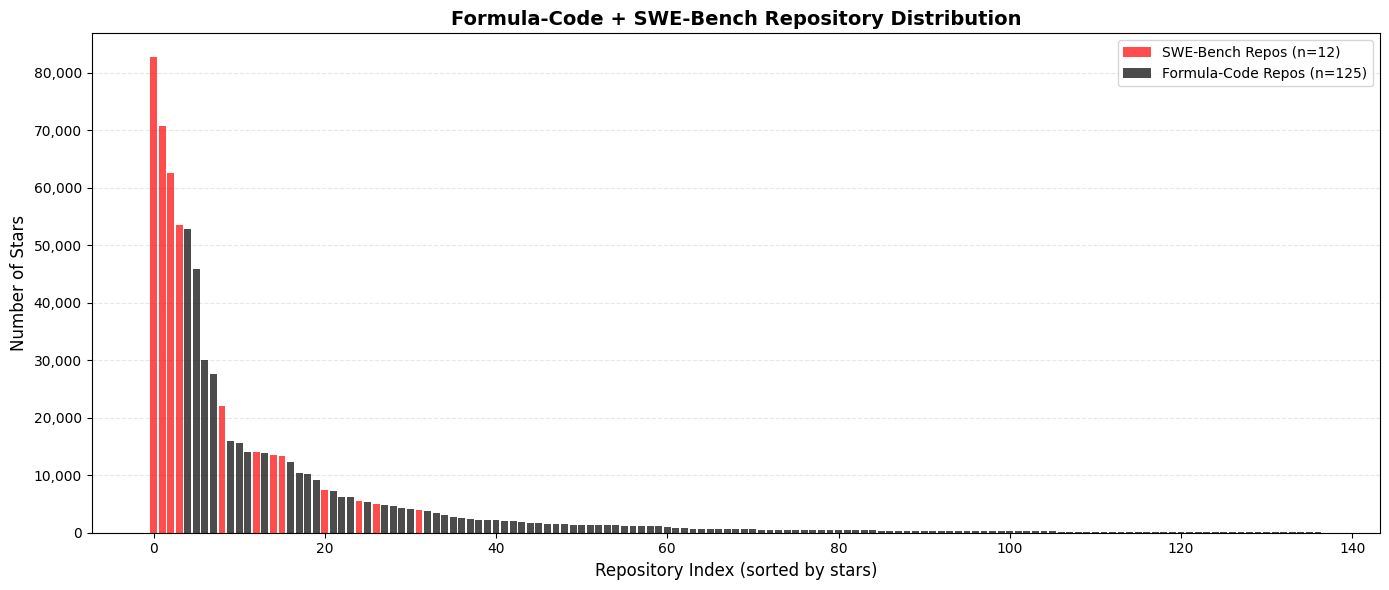


Summary Statistics:
Total repos: 137
SWE-Bench repos: 12
Formula-Code-only repos: 125

Star distribution (all repos):
  Min: 105
  Max: 82,700
  Mean: 5,345
  Median: 608

Star distribution (SWE-Bench repos only):
  Min: 3,893
  Max: 82,700
  Mean: 29,550
  Median: 13,772


In [10]:
import matplotlib.pyplot as plt
import numpy as np

# Create the plot
fig, ax = plt.subplots(figsize=(14, 6))

# Create colors array: red for SWE-Bench, black for others
colors = ["red" if is_swe else "black" for is_swe in repos_df_sorted["is_swe_bench"]]

# Create bar plot - each repo gets its own bar
x_pos = np.arange(len(repos_df_sorted))
bars = ax.bar(x_pos, repos_df_sorted["stars"], color=colors, alpha=0.7, edgecolor="none")

# Customize the plot
ax.set_xlabel("Repository Index (sorted by stars)", fontsize=12)
ax.set_ylabel("Number of Stars", fontsize=12)
ax.set_title("Formula-Code + SWE-Bench Repository Distribution", fontsize=14, fontweight="bold")

# Add grid for better readability
ax.grid(axis="y", alpha=0.3, linestyle="--")
ax.set_axisbelow(True)

# Format y-axis to show numbers with commas
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f"{int(x):,}"))

# Add legend
from matplotlib.patches import Patch

legend_elements = [
    Patch(facecolor="red", alpha=0.7, label=f"SWE-Bench Repos (n={repos_df_sorted['is_swe_bench'].sum()})"),
    Patch(facecolor="black", alpha=0.7, label=f"Formula-Code Repos (n={(~repos_df_sorted['is_swe_bench']).sum()})"),
]
ax.legend(handles=legend_elements, loc="upper right", fontsize=10)

# Tight layout
plt.tight_layout()
plt.show()

# Print summary statistics
print("\nSummary Statistics:")
print(f"Total repos: {len(repos_df_sorted)}")
print(f"SWE-Bench repos: {repos_df_sorted['is_swe_bench'].sum()}")
print(f"Formula-Code-only repos: {(~repos_df_sorted['is_swe_bench']).sum()}")
print("\nStar distribution (all repos):")
print(f"  Min: {repos_df_sorted['stars'].min():,}")
print(f"  Max: {repos_df_sorted['stars'].max():,}")
print(f"  Mean: {repos_df_sorted['stars'].mean():,.0f}")
print(f"  Median: {repos_df_sorted['stars'].median():,.0f}")

# SWE-Bench specific stats
swe_bench_stars = repos_df_sorted[repos_df_sorted["is_swe_bench"]]["stars"]
print("\nStar distribution (SWE-Bench repos only):")
print(f"  Min: {swe_bench_stars.min():,}")
print(f"  Max: {swe_bench_stars.max():,}")
print(f"  Mean: {swe_bench_stars.mean():,.0f}")
print(f"  Median: {swe_bench_stars.median():,.0f}")